# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama:Krisna Putra Wicaksana
- Email:krisnaputrawicaksana2005@gmail.com
- Id Dicoding: krisna putra wicaksana

## Persiapan

### Menyiapkan library yang dibutuhkan

In [33]:
# IMPORT LIBRARY DATA MANIPULATION & MATH
import pandas as pd
import numpy as np

# IMPORT LIBRARY DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORT LIBRARY DATABASE & MODEL EXPORT
import joblib

# IMPORT LIBRARY MACHINE LEARNING (SCIKIT-LEARN)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV

### Menyiapkan data yang akan digunakan

## Data Understanding

In [2]:
df = pd.read_csv("data.csv", sep=';')
display(df.head())

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()
print("Cek duplikasi data: ", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
# Melihat statistik deskriptif (rata-rata, nilai min/max, sebaran)
print("statistik desriptif")
display(df.describe(include='all'))

statistik desriptif


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [5]:
# Kolom Target
target_col = 'Status'

# Daftar kolom yang benar-benar berisi angka kontinu/diskrit berbobot
num_cols = [
    'Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment',
    'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

# Sisanya kita anggap sebagai kolom kategorikal
cat_cols = [col for col in df.columns if col not in num_cols and col != target_col]

print(f"Jumlah kolom numerik: {len(num_cols)}")
print(f"Jumlah kolom kategorikal: {len(cat_cols)}")

Jumlah kolom numerik: 18
Jumlah kolom kategorikal: 18


Proporsi target: 
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


C:\Users\KRISNA PUTRA\AppData\Local\Temp\ipykernel_31520\1860110894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette={'Dropout': '#FF6B6B', 'Graduate': '#4ECDC4', 'Enrolled': '#FFE66D'})


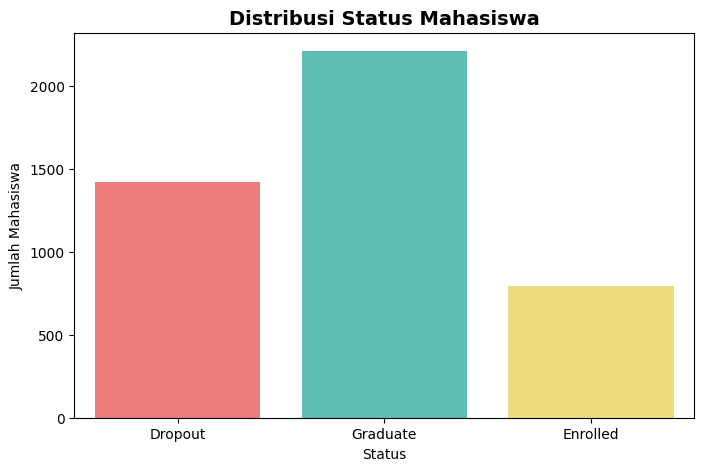

In [6]:
# Cek persentase Status
print("Proporsi target: ")
print(df[target_col].value_counts(normalize=True)*100)

# Visualisasi
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col, palette={'Dropout': '#FF6B6B', 'Graduate': '#4ECDC4', 'Enrolled': '#FFE66D'})
plt.title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

### Insight: Distribusi Status Mahasiswa (Target)
Berdasarkan visualisasi proporsi target, kita dapat melihat bahwa:
* Mayoritas mahasiswa dalam dataset ini berhasil lulus (**Graduate**: ~49.9%).
* Tingkat kegagalan cukup memprihatinkan, di mana sekitar sepertiga mahasiswa memutuskan berhenti (**Dropout**: ~32.1%).
* Sisanya masih berstatus aktif (**Enrolled**: ~17.9%).

**Tindak Lanjut Business Understanding:** Kelas `Enrolled` merepresentasikan status yang belum selesai (menggantung). Untuk membangun model prediktif yang tajam dalam membedakan karakteristik siswa yang "sukses" versus "gagal", kita bisa mempertimbangkan untuk menghapus baris data dengan status `Enrolled` pada tahap *Data Preparation* nanti, sehingga mengubah kasus ini menjadi *Binary Classification* (Dropout vs Graduate).

C:\Users\KRISNA PUTRA\AppData\Local\Temp\ipykernel_31520\1887398289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='Age_at_enrollment', palette='Set2')


<function matplotlib.pyplot.show(close=None, block=None)>

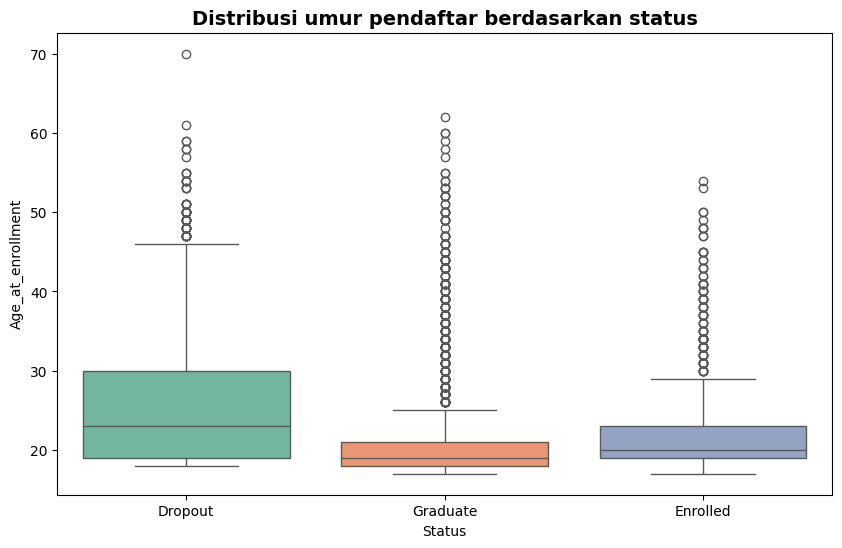

In [7]:
# Melihat hubungan umur saat mendaftar dengan Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=target_col, y='Age_at_enrollment', palette='Set2')
plt.title('Distribusi umur pendaftar berdasarkan status', fontsize=14, fontweight='bold')
plt.show

### Insight: Pengaruh Umur Terhadap Tingkat Dropout
Analisis menggunakan *boxplot* pada fitur `Age_at_enrollment` menunjukkan pola yang menarik:
* Kelompok mahasiswa yang **Dropout** memiliki median umur yang lebih tinggi dibandingkan kelompok **Graduate** dan **Enrolled**.
* Sebaran data (kuartil atas dan bawah) pada kelompok Dropout juga lebih lebar ke atas.
* **Kesimpulan awal:** Mahasiswa yang mendaftar di usia yang lebih tua memiliki risiko *dropout* yang lebih tinggi. Hal ini berpotensi disebabkan oleh faktor eksternal seperti tuntutan pekerjaan atau tanggung jawab keluarga. Ini adalah temuan krusial untuk rancangan intervensi Jaya Jaya Institut.

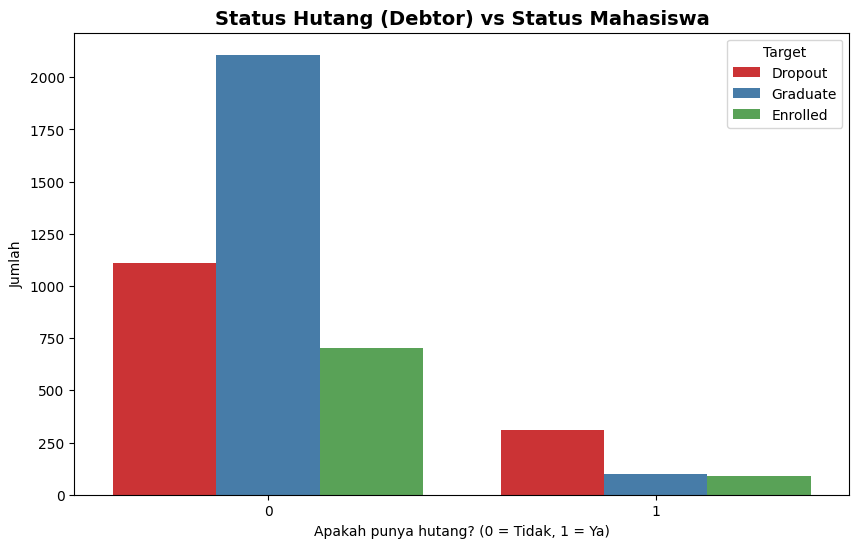

In [8]:
# Melihat hubungan status Hutang (Debtor) dengan Target
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Debtor', hue=target_col, palette='Set1')
plt.title('Status Hutang (Debtor) vs Status Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Apakah punya hutang? (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.legend(title='Target')
plt.show()

### Insight: Status Finansial (Hutang) sebagai Indikator Kuat
Visualisasi `Debtor` (Status Hutang) memperlihatkan korelasi yang sangat kuat dengan status akademik:
* Pada kelompok mahasiswa yang **tidak memiliki hutang** (0), tingkat kelulusan sangat mendominasi dibandingkan tingkat *dropout*.
* Sebaliknya, pada kelompok mahasiswa yang **memiliki hutang** (1), rasio *dropout* meroket drastis dan jauh melampaui rasio kelulusan.
* **Kesimpulan awal:** Kesulitan finansial (tercermin dari status *Debtor*) adalah salah satu prediktor paling kuat untuk *dropout*. Fitur ini akan sangat berpengaruh dalam pemodelan *Machine Learning* nanti.

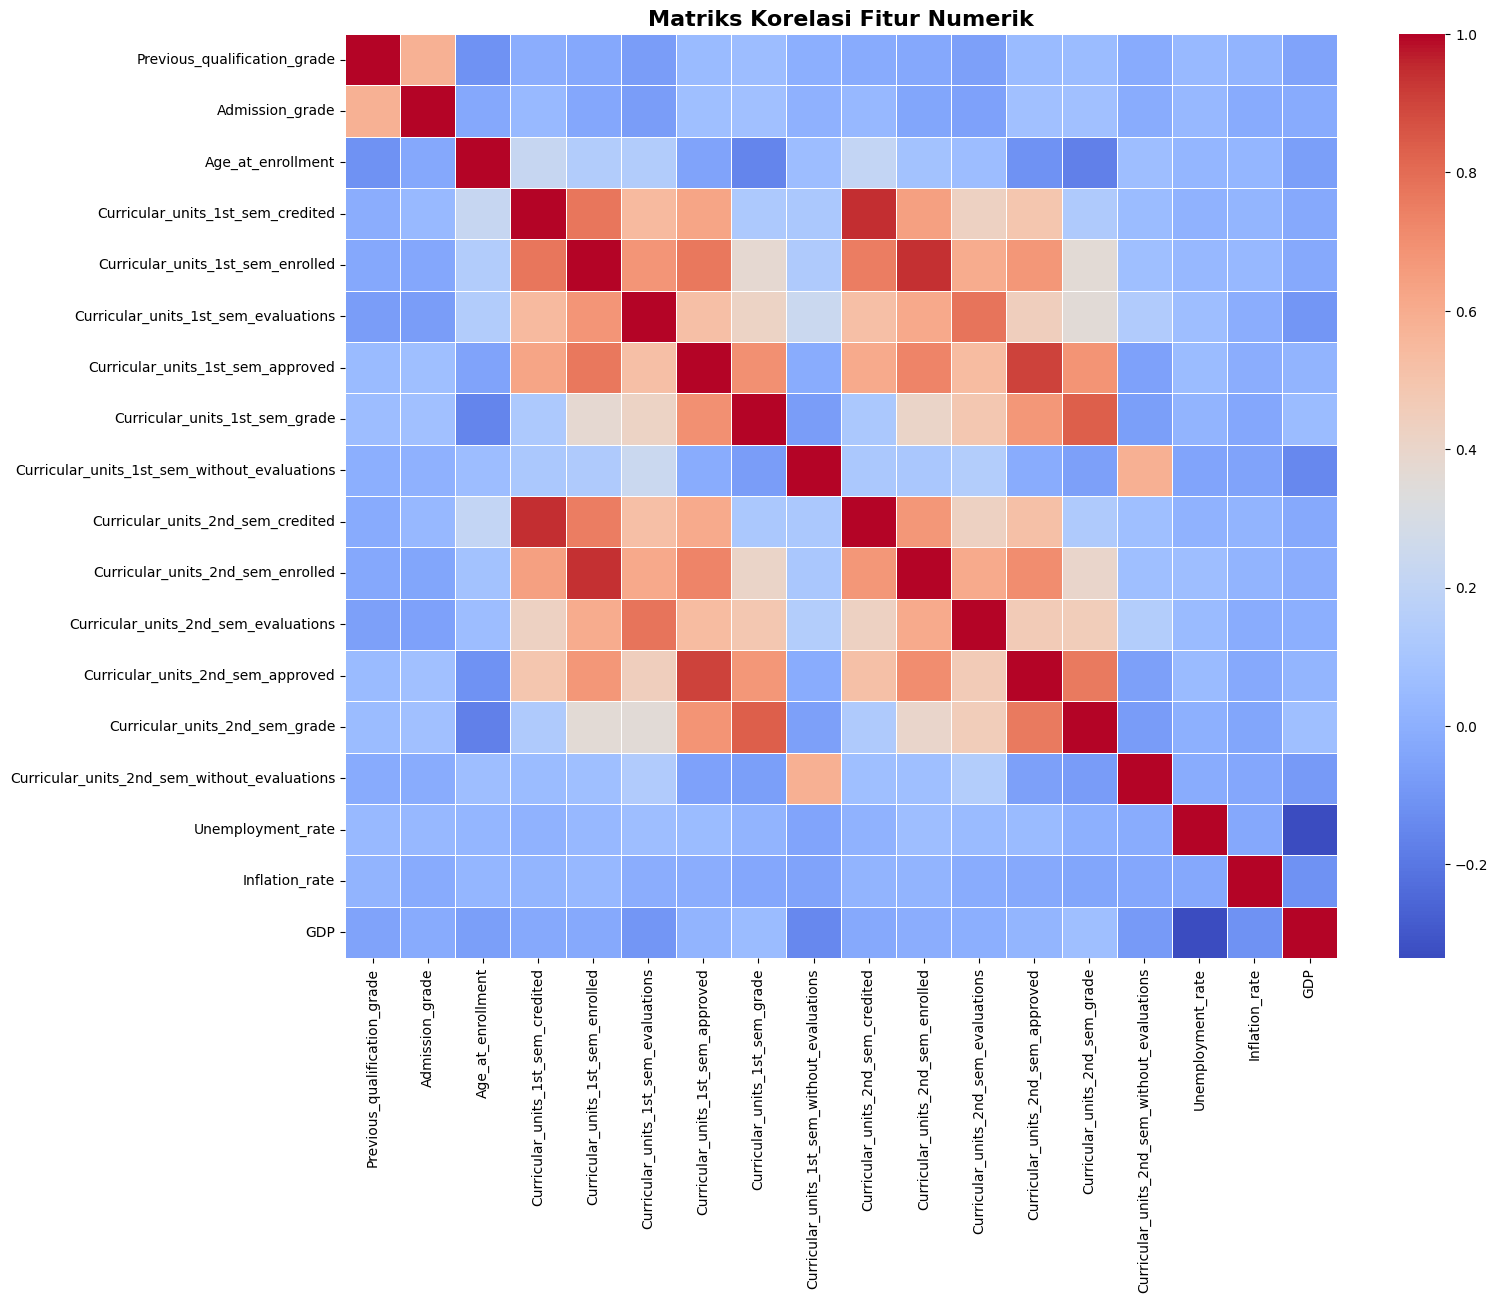

In [9]:
# Peta Korelasi (Hanya untuk fitur numerik)
plt.figure(figsize=(16, 12))
# Hitung korelasi
corr_matrix = df[num_cols].corr()
# Gambar Heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=16, fontweight='bold')
plt.show()

### Insight: Matriks Korelasi (Multikolinearitas & Makroekonomi)
Dari *Heatmap* korelasi antar fitur numerik, ditemukan beberapa temuan teknis:
1. **Korelasi Akademik Kuat:** Terdapat korelasi positif yang sangat kuat (blok merah gelap) antara fitur-fitur akademik Semester 1 dengan Semester 2 (contoh: `Curricular_units_1st_sem_approved` dengan `Curricular_units_2nd_sem_approved`). Hal ini mengindikasikan adanya *Multicollinearity*. Mahasiswa yang berprestasi di semester 1 cenderung konsisten di semester 2.
2. **Korelasi Makroekonomi Lemah:** Fitur makroekonomi seperti `GDP`, `Inflation_rate`, dan `Unemployment_rate` memiliki warna yang sangat pudar/kebiruan terhadap fitur akademik. Ini menunjukkan korelasi linear yang sangat lemah terhadap performa belajar mahasiswa.
3. **Strategi Deteksi Dini:** Mengingat tujuan bisnis adalah mendeteksi *dropout* **sedini mungkin**, kita berpeluang untuk mendrop seluruh fitur *Semester 2*. Jika kita menunggu nilai Semester 2 keluar untuk memprediksi, mungkin itu sudah terlambat bagi kampus untuk memberikan bimbingan.

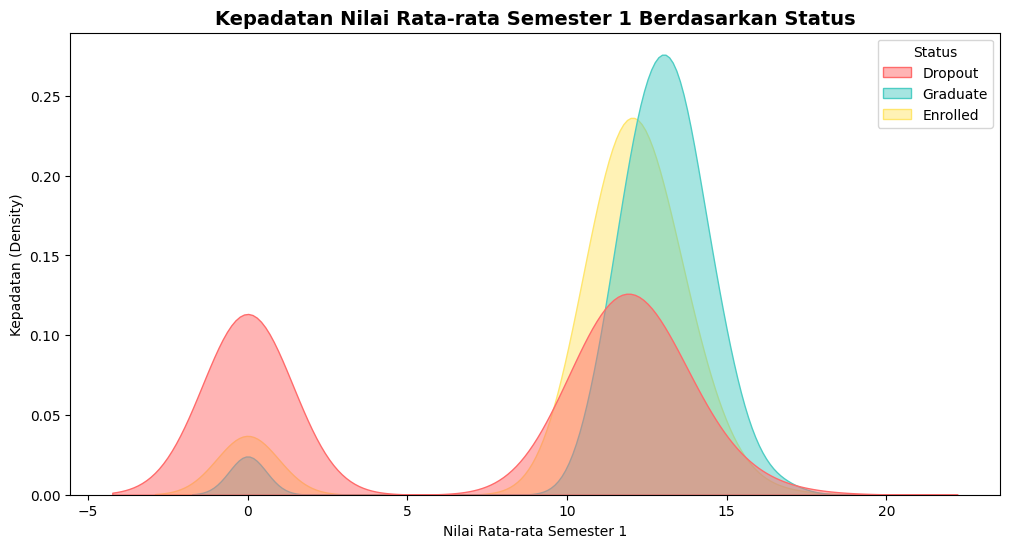

In [10]:
# Distribusi Nilai Semester 1 (Melihat Posisi 'Enrolled')

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Curricular_units_1st_sem_grade', hue='Status', 
            fill=True, common_norm=False, palette={'Dropout': '#FF6B6B', 'Graduate': '#4ECDC4', 'Enrolled': '#FFE66D'}, alpha=0.5)
plt.title('Kepadatan Nilai Rata-rata Semester 1 Berdasarkan Status', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Rata-rata Semester 1')
plt.ylabel('Kepadatan (Density)')
plt.show()

### Insight: Analisis Performa Akademik Semester Awal (KDE Plot)
Melalui plot kepadatan distribusi (KDE) pada rata-rata nilai semester 1, kita menemukan pola yang sangat tajam:
* **Puncak Ekstrem Dropout di Angka 0:** Terdapat anomali berupa lonjakan ekstrem mahasiswa *Dropout* (merah) yang mendapatkan nilai 0. Ini mengindikasikan bahwa tanda bahaya *dropout* sudah terlihat sangat dini, di mana mahasiswa tersebut mungkin sudah berhenti berpartisipasi sejak awal semester.
* **Karakteristik Mahasiswa 'Enrolled':** Kurva mahasiswa berstatus *Enrolled* (kuning) memiliki bentuk normal yang hampir identik dengan kurva mahasiswa lulus/*Graduate* (hijau), namun puncaknya berada di nilai yang sedikit lebih rendah. 
* **Kesimpulan Bisnis:** Mahasiswa *Enrolled* bukanlah kelompok yang pasti gagal, melainkan kelompok "pejuang menengah". Intervensi akademik yang tepat sasaran di semester-semester awal bisa mendorong mereka bergeser ke kelompok lulusan.

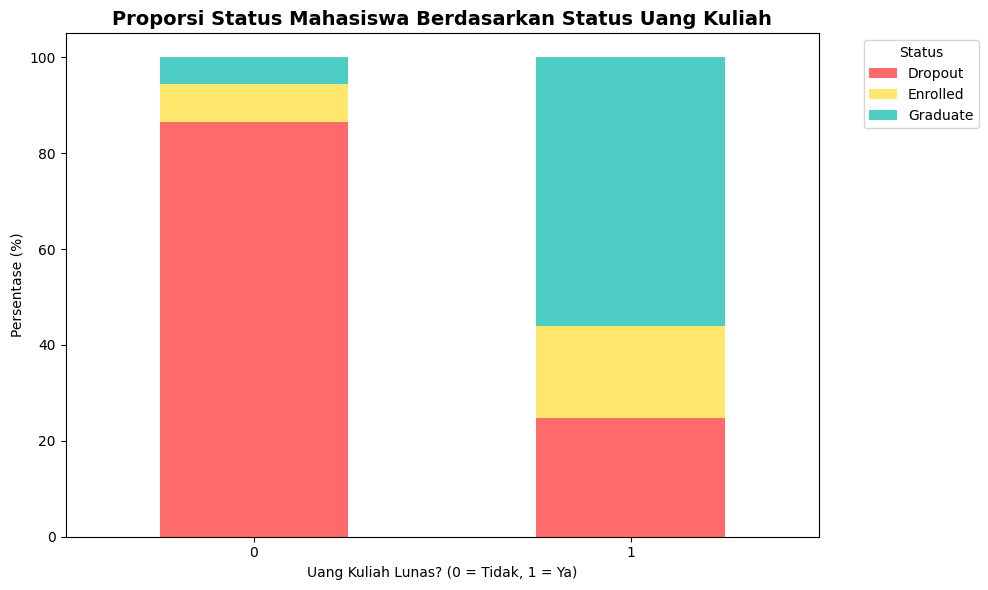

In [11]:
# Kepatuhan Pembayaran Uang Kuliah (Tuition fees up to date)
# Kita hitung persentase baris agar adil, karena jumlah tiap kelas berbeda
cross_tab_tuition = pd.crosstab(df['Tuition_fees_up_to_date'], df['Status'], normalize='index') * 100

cross_tab_tuition.plot(kind='bar', stacked=True, figsize=(10, 6), 
                       color=['#FF6B6B', '#FFE66D', '#4ECDC4'])
plt.title('Proporsi Status Mahasiswa Berdasarkan Status Uang Kuliah', fontsize=14, fontweight='bold')
plt.xlabel('Uang Kuliah Lunas? (0 = Tidak, 1 = Ya)')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight: Tunggakan Uang Kuliah sebagai Alarm Utama
Visualisasi proporsi status mahasiswa terhadap kepatuhan pembayaran uang kuliah (`Tuition_fees_up_to_date`) menunjukkan korelasi kausalitas yang sangat kuat:
* Kelompok mahasiswa yang **menunggak uang kuliah** (kategori 0) memiliki probabilitas kegagalan studi yang sangat fatal, di mana lebih dari 80% di antaranya berakhir dengan status *Dropout*.
* Pada kelompok mahasiswa yang **pembayarannya lancar** (kategori 1), proporsi *dropout* menyusut drastis menjadi minoritas (sekitar 20-25%).
* **Kesimpulan Bisnis:** Tunggakan administrasi finansial adalah metrik deteksi dini (Early Warning System) yang paling efektif. Jaya Jaya Institut harus memprioritaskan pemantauan ketat pada mahasiswa yang mulai terlambat membayar.

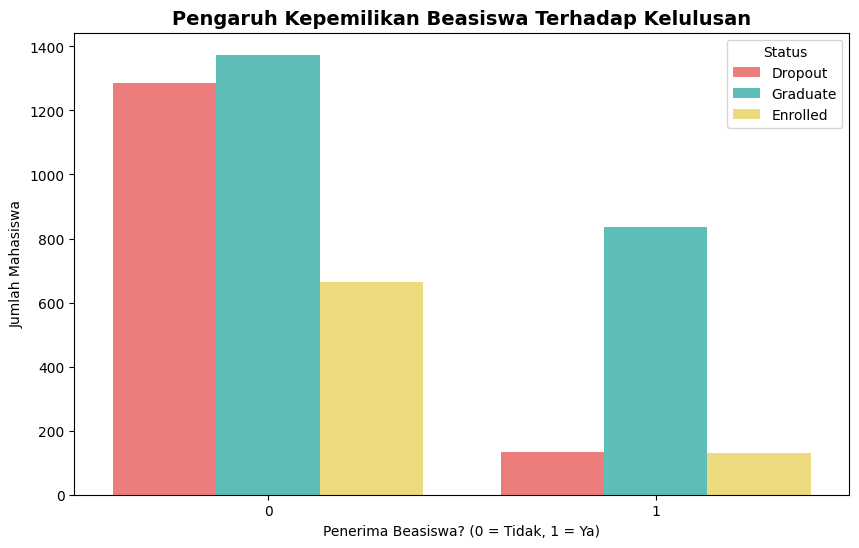

In [12]:
# Analisis Pengaruh Beasiswa (Scholarship holder)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Scholarship_holder', hue='Status', 
              palette={'Dropout': '#FF6B6B', 'Graduate': '#4ECDC4', 'Enrolled': '#FFE66D'})
plt.title('Pengaruh Kepemilikan Beasiswa Terhadap Kelulusan', fontsize=14, fontweight='bold')
plt.xlabel('Penerima Beasiswa? (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

### Insight: Beasiswa sebagai Faktor Pelindung (Protective Factor)
Grafik distribusi penerima beasiswa (`Scholarship_holder`) memperlihatkan efektivitas bantuan finansial:
* Pada kelompok mahasiswa **tanpa beasiswa** (0), tingkat *Dropout* sangat tinggi dan bersaing ketat dengan jumlah mahasiswa yang lulus.
* Pada kelompok mahasiswa **penerima beasiswa** (1), rasio kelulusan melesat tinggi sementara rasio *Dropout* ditekan hingga level yang sangat minimal.
* **Kesimpulan Bisnis:** Bantuan finansial (beasiswa) terbukti menjadi jaring pengaman (*safety net*) yang luar biasa efektif. Jika kampus ingin menyelamatkan mahasiswa yang rentan (*terutama kelompok Enrolled yang kesulitan finansial*), memperluas cakupan beasiswa bersyarat bisa menjadi *Action Item* yang strategis.

## Data Preparation / Preprocessing

In [13]:
# Feature Selection (Mencegah Kebocoran Data)
# Cari semua kolom yang mengandung kata '2nd_sem'
cols_to_drop = [col for col in df.columns if '2nd_sem' in col]

# Membuat dataframe baru (df_prep) yang membuang kolom-kolom tersebut
df_prep = df.drop(columns=cols_to_drop)

print(f"Jumlah kolom sebelum: {df.shape[1]}")
print(f"Jumlah kolom setelah dibuang: {df_prep.shape[1]}")
print(f"Kolom yang dibuang: {cols_to_drop}")

Jumlah kolom sebelum: 37
Jumlah kolom setelah dibuang: 31
Kolom yang dibuang: ['Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations']


In [24]:
# 1. FILTER DATA: Buang status 'Enrolled' (Gunakan df_prep sebagai sumber)
df_model = df_prep[df_prep['Status'] != 'Enrolled'].copy()

# 2. Memisahkan Fitur (X) dan Target (y) menggunakan data yang sudah bersih (df_model)
X = df_model.drop(columns=['Status'])
y = df_model['Status']

# 3. Ubah text menjadi angka 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Cek hasil mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapping Target: {label_mapping}")

Mapping Target: {'Dropout': 0, 'Graduate': 1}


In [25]:
# Train-Test Split

# Bagi data: 80% untuk belajar (Train), 20% untuk ujian (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Jumlah data latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah data uji (Test): {X_test.shape[0]} baris")

Jumlah data latih (Train): 2904 baris
Jumlah data uji (Test): 726 baris


In [26]:
# Preprocessing Pipeline (Scaling & Encoding)

# Update daftar kolom numerik dan kategorikal
num_cols_prep = [col for col in num_cols if col not in cols_to_drop]
cat_cols_prep = [col for col in cat_cols if col not in cols_to_drop]

# Buat pengubahnya
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_prep),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_prep)
    ])

# fit_transform untuk Train, transform saja untuk Test)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Jumlah kolom fitur setelah di-encode menjadi banyak: {X_train_prep.shape[1]}")

Jumlah kolom fitur setelah di-encode menjadi banyak: 234


In [27]:
# Handling Imbalance Data dengan SMOTE

from imblearn.over_sampling import SMOTE

# Terapkan SMOTE pada data latih yang sudah di-preprocess
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_prep, y_train)
unique, counts = np.unique(y_train_balanced, return_counts=True)
hasil_smote = dict(zip(le.classes_, counts))

print("\nProporsi kelas pada Training Set SETELAH SMOTE:")
for status, jumlah in hasil_smote.items():
    print(f"- {status}: {jumlah} mahasiswa")


Proporsi kelas pada Training Set SETELAH SMOTE:
- Dropout: 1767 mahasiswa
- Graduate: 1767 mahasiswa


### Insight : 
Seperti yang kita temukan di EDA, jumlah Dropout (32%) dan Enrolled (18%) lebih sedikit dari Graduate (50%). Model bisa jadi malas dan cuma nebak "Graduate" terus karena itu mayoritas. SMOTE (Synthetic Minority Over-sampling Technique) akan menduplikasi/mensintesis data Dropout dan Enrolled buatan di Data Latih agar jumlah ketiganya seimbang persis.

## Modeling

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Inisiasi Model Random Forest
# n_estimators=100 (jumlah pohon keputusan), random_state=42 (agar hasil bisa konsisten)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Memulai proses training model Random Forest...")

# Latih model menggunakan data training (X_train_balanced dan y_train_balanced)
rf_model.fit(X_train_balanced, y_train_balanced)

print("Training selesai! Model siap digunakan.")

Memulai proses training model Random Forest...
Training selesai! Model siap digunakan.


In [29]:
# HYPERPARAMETER TUNING (RANDOM FOREST)

# Menentukan ruang parameter yang mau diuji
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Inisiasi pencarian parameter terbaik
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_grid, 
    n_iter=15, 
    cv=3, 
    verbose=1, 
    random_state=42, 
    scoring='f1_macro'
)

# Latih model
print("Sedang mencari parameter terbaik...")
rf_random.fit(X_train_balanced, y_train_balanced)

# Tampilkan hasil parameter terbaik yang berhasil ditemukan
print("\nParameter Terbaik:\n", rf_random.best_params_)

# 5. Simpan model pemenang ke variabel baru
best_rf_model = rf_random.best_estimator_
print("Model terbaik siap dievaluasi!")

Sedang mencari parameter terbaik...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Parameter Terbaik:
 {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Model terbaik siap dievaluasi!


## Evaluation


--- Classification Report: Random Forest (Tuned) ---
              precision    recall  f1-score   support

     Dropout       0.90      0.80      0.84       284
    Graduate       0.88      0.94      0.91       442

    accuracy                           0.89       726
   macro avg       0.89      0.87      0.88       726
weighted avg       0.89      0.89      0.88       726



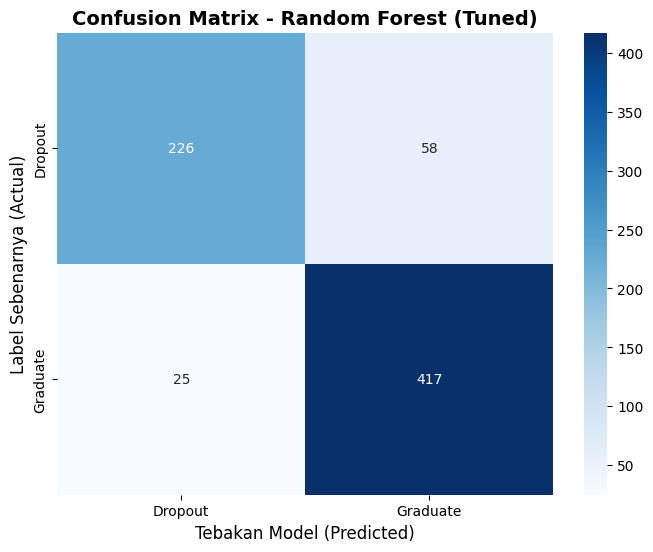

In [30]:
# EVALUASI MODEL TERBAIK (TUNED MODEL)
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi menggunakan model hasil tuning
y_pred_tuned = best_rf_model.predict(X_test_prep)
print("\n--- Classification Report: Random Forest (Tuned) ---")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# Visualisasi Confusion Matrix untuk model terbaik
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
    
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest (Tuned)', fontsize=14, fontweight='bold')
plt.ylabel('Label Sebenarnya (Actual)', fontsize=12)
plt.xlabel('Tebakan Model (Predicted)', fontsize=12)
plt.show()

In [31]:
# Menyimpan model data
import os
os.makedirs('model', exist_ok=True)

# Simpan model pemenang dan mesin preprocessor
joblib.dump(best_rf_model, 'model/rf_model.joblib')
joblib.dump(preprocessor, 'model/preprocessor.joblib')

print("Model dan Preprocessor berhasil di-export ke folder 'model'.")

Model dan Preprocessor berhasil di-export ke folder 'model'.


In [32]:
# Salin dataset awal agar data mentah tidak berubah
df_dashboard = df.copy()

# Mapping nilai biner (1/0) menjadi teks (Yes/No) agar mudah dibaca di Dashboard
mapping_ya_tidak = {1: 'Yes', 0: 'No'}

df_dashboard['Debtor_Label'] = df_dashboard['Debtor'].map(mapping_ya_tidak)
df_dashboard['Tuition_fees_Label'] = df_dashboard['Tuition_fees_up_to_date'].map(mapping_ya_tidak)
df_dashboard['Scholarship_Label'] = df_dashboard['Scholarship_holder'].map(mapping_ya_tidak)

# Mapping Gender (1 = Male, 0 = Female)
df_dashboard['Gender_Label'] = df_dashboard['Gender'].map({1: 'Male', 0: 'Female'})

# Menyimpan dataset yang sudah bersih dan terbaca ini ke dalam CSV baru
df_dashboard.to_csv('dashboard_data_clean.csv', index=False)

print("Data untuk Dashboard berhasil disimpan sebagai 'dashboard_data_clean.csv'!")

Data untuk Dashboard berhasil disimpan sebagai 'dashboard_data_clean.csv'!
